# Testing the model

In [1]:
# Set the base dir to the project root
%cd ..
!pwd

/home/pere/pbi
/home/pere/pbi


/home/pere/micromamba/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import torch
import pandas as pd
import os
from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput
from main import parse_config, reduce_dimensionality, test_model, make_dataset
import numpy as np
import matplotlib.pyplot as plt


In [3]:
config = parse_config(config_path="model_configs/best_model_pbip_datasets.yaml")

device = "cpu"

[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 16384
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 16384
[INFO] Configuration loaded from model_configs/best_model_pbip_datasets.yaml: Config(input_perphect=bacteria_df='data/perphect-data/predphi/bacteria_sequences.csv' phages_df='data/perphect-data/predphi/bacteriophages_sequences.csv' couples_df='data/perphect-data/predphi/predphi_train_dataset.csv', embeddings_dir=data/embeddings-pbip, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True do_test=False epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 training_noise_std=0.05 stratify_cv=False k_folds_cv=10 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='none' n_components_bacteria=None n_components_phages=None), phages_embedding_models=[NT2(merging_strategy=TopBottomTruncateStrategy(), overlap=0, model_name='nucleotide-t

### Load dataset

In [4]:
# Hardcode test dataset path. Only used for the PredPHI data, on the CI4CB data, ignore this cell.
config.input_perphect.couples_df = "data/perphect-data/predphi/predphi_test_dataset.csv"

In [5]:
# Assumming that all the embeddings have already been computed
output_manager = H5pyEmbeddingsManager(config.embeddings_dir)

[INFO] Embeddings will be stored or read from data/embeddings-pbip


In [6]:
bacteria_df, phages_df, couples_df = PerphectDataInput(input_paths=config.input_perphect).load()

[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_test_dataset.csv
[INFO] Reading csv files...


In [ ]:
bacteria_model_names = [x.name() for x in config.bacteria_embedding_models]
phages_model_names = [x.name() for x in config.phages_embedding_models]
dataset = make_dataset(couples_df, bacteria_model_names, phages_model_names, output_manager, device)
dataset = reduce_dimensionality(dataset, config.training_config.reduce_dimensionality, config.output_dir, config.training_config.n_components_bacteria, config.training_config.n_components_phages)


In [8]:
dataset.head()

,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding
0,NC_019400,CALF01000071,1,"[tensor(0.0652), tensor(0.0152), tensor(0.2972...","[tensor(0.1758), tensor(0.2331), tensor(0.2490..."
1,MF919516,CP012196,0,"[tensor(-0.0643), tensor(-0.0283), tensor(0.82...","[tensor(0.3073), tensor(0.4169), tensor(0.5371..."
2,NC_019813,CP011132,0,"[tensor(0.0619), tensor(0.1624), tensor(0.7857...","[tensor(0.0379), tensor(0.1556), tensor(0.2032..."
3,NC_027355,CM000736,1,"[tensor(-0.0317), tensor(-0.2202), tensor(0.08...","[tensor(0.0881), tensor(-0.1265), tensor(0.036..."
4,NC_021790,CP009976,1,"[tensor(-0.1541), tensor(-0.6002), tensor(0.02...","[tensor(0.0610), tensor(0.0364), tensor(0.3254..."


### Load the model
Make sure to use the same architecture and parameters that were used for training it. See the yaml file that was used.

In [9]:
model_path = os.path.join(config.output_dir, "trained_model.pth")

In [10]:
bacterium_embed_size = len(dataset["bacterium_embedding"].iloc[0])
phage_embed_size = len(dataset["phage_embedding"].iloc[0])
model = config.classifier(bacterium_embed_size, phage_embed_size, **config.classifier_params)

model.load_state_dict(torch.load(model_path, map_location=device))

<All keys matched successfully>

### Test the model

In [11]:
test_model(dataset, model, batch_size=config.training_config.batch_size, device=device);

[INFO] Starting testing...
[INFO] Accuracy (test): 0.7427184581756592
[INFO] Recall (test): 0.7038834691047668
[INFO] F1 score (test): 0.7323232293128967
[INFO] Loss (test): 0.669065247654529
[INFO] Confusion Matrix (test) (TP, FP, FN, TN): (435, 135, 183, 483)


### Do 1 prediction

In [12]:
# Do 1 prediction example
example = dataset.iloc[0]
bacterium_embedding = example["bacterium_embedding"].clone().detach().unsqueeze(0).to(device)
phage_embedding = example["phage_embedding"].clone().detach().unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output = model(bacterium_embedding, phage_embedding)
    probs = torch.sigmoid(output).squeeze().cpu().numpy()
    print(f"Predicted interaction probability for bacterium {example['bacterium_id']} and phage {example['phage_id']}: Label {np.argmax(probs)} with probability {np.max(probs):.6f}. True label: {example['interaction_type']}")

Predicted interaction probability for bacterium CALF01000071 and phage NC_019400: Label 0 with probability 0.666239. True label: 1


### View missed predictions

In [13]:
dataset[["prediction", "probability"]] = dataset.apply(
    lambda row: pd.Series({
        "prediction": int(torch.argmax(torch.sigmoid(model(
            row["bacterium_embedding"].unsqueeze(0).to(device),
            row["phage_embedding"].unsqueeze(0).to(device)
        ))).squeeze().detach().cpu().numpy()),
        "probability": float(torch.max(torch.sigmoid(model(
            row["bacterium_embedding"].unsqueeze(0).to(device),
            row["phage_embedding"].unsqueeze(0).to(device)
        ))).squeeze().detach().cpu().numpy())
    }), axis=1
)
dataset.head()

,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding,prediction,probability
0,NC_019400,CALF01000071,1,"[tensor(0.0652), tensor(0.0152), tensor(0.2972...","[tensor(0.1758), tensor(0.2331), tensor(0.2490...",0.0,0.666239
1,MF919516,CP012196,0,"[tensor(-0.0643), tensor(-0.0283), tensor(0.82...","[tensor(0.3073), tensor(0.4169), tensor(0.5371...",0.0,0.892348
2,NC_019813,CP011132,0,"[tensor(0.0619), tensor(0.1624), tensor(0.7857...","[tensor(0.0379), tensor(0.1556), tensor(0.2032...",0.0,0.948882
3,NC_027355,CM000736,1,"[tensor(-0.0317), tensor(-0.2202), tensor(0.08...","[tensor(0.0881), tensor(-0.1265), tensor(0.036...",0.0,0.901090
4,NC_021790,CP009976,1,"[tensor(-0.1541), tensor(-0.6002), tensor(0.02...","[tensor(0.0610), tensor(0.0364), tensor(0.3254...",1.0,0.935293


In [14]:
dataset["phage_id"].value_counts()

phage_id
NC_028799    6
MK433271     5
NC_028684    5
NC_009936    5
NC_028933    5
            ..
NC_014789    1
NC_024785    1
NC_017974    1
NC_016659    1
NC_021312    1
Name: count, Length: 618, dtype: int64

In [15]:
dataset[dataset["interaction_type"] != dataset["prediction"]]["phage_id"].value_counts()

phage_id
NC_019919    3
NC_022974    3
NC_001331    3
NC_016165    3
NC_029081    3
            ..
NC_031034    1
NC_023841    1
MF975638     1
NC_019518    1
NC_028974    1
Name: count, Length: 275, dtype: int64

In [16]:
dataset[dataset["interaction_type"] != dataset["prediction"]]["bacterium_id"].value_counts()

bacterium_id
HG530068        44
CP010812        23
JTHH01000008    18
CM000736        17
AP009493        12
                ..
CP013197         1
CP009902         1
CP004014         1
FN543502         1
CP001807         1
Name: count, Length: 89, dtype: int64

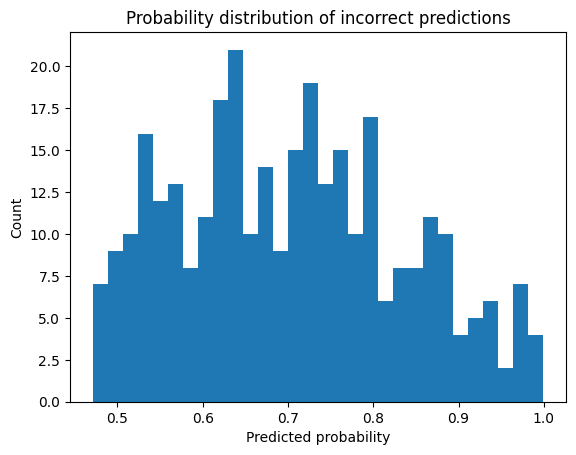

In [17]:
dataset[dataset["interaction_type"] != dataset["prediction"]]["probability"].hist(bins=30)
plt.title("Probability distribution of incorrect predictions")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.grid(False)
plt.show()

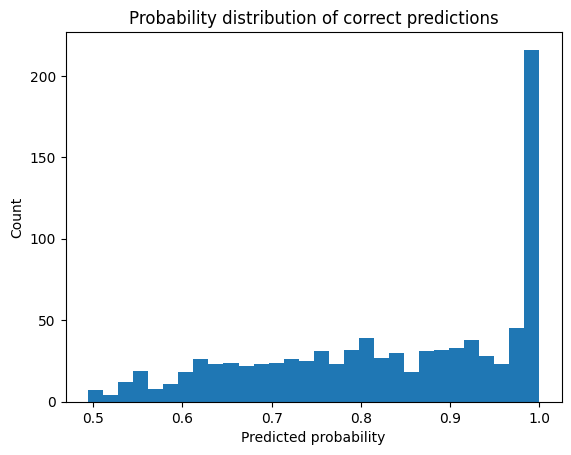

In [18]:
dataset[dataset["interaction_type"] == dataset["prediction"]]["probability"].hist(bins=30)
plt.title("Probability distribution of correct predictions")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.grid(False)
plt.show()